In [92]:
## 1. Exploratory Data Analysis (EDA) | Análisis Exploratorio de Datos (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EN: Load dataset
# ES: Cargar el conjunto de datos
df = pd.read_csv("00_bmw_sales.csv")

In [93]:
# EN: Standardize column names (Lowercase and whitespace removal) 
# ES: Estandarizar nombres de columnas (Minúsculas y eliminación de espacios)

df.columns = df.columns.str.lower().str.strip()
print(df.columns)

Index(['year', 'month', 'region', 'model', 'units_sold', 'avg_price_eur',
       'revenue_eur', 'bev_share', 'premium_share', 'gdp_growth',
       'fuel_price_index'],
      dtype='str')


In [94]:
# EN: Initial data preview
# ES: Vista previa inicial de los datos

print(df.head())

   year  month  region     model  units_sold  avg_price_eur  revenue_eur  \
0  2018      1  Europe  3 Series        7822          47482    371404204   
1  2018      1  Europe  5 Series       10280          61685    634121800   
2  2018      1  Europe        X3        3105          58433    181434465   
3  2018      1  Europe        X5        7420          67955    504226100   
4  2018      1  Europe        X7        8474          92300    782150200   

   bev_share  premium_share  gdp_growth  fuel_price_index  
0      0.011          19.12         3.5               1.0  
1      0.019          19.12         3.5               1.0  
2      0.022          19.12         3.5               1.0  
3      0.021          19.12         3.5               1.0  
4      0.035          19.12         3.5               1.0  


In [95]:
# EN: Dataset metadata (Data types and non-null counts) 
# ES: Metadatos del dataset (Tipos de datos y conteos no nulos)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              3072 non-null   int64  
 1   month             3072 non-null   int64  
 2   region            3072 non-null   str    
 3   model             3072 non-null   str    
 4   units_sold        3072 non-null   int64  
 5   avg_price_eur     3072 non-null   int64  
 6   revenue_eur       3072 non-null   int64  
 7   bev_share         3072 non-null   float64
 8   premium_share     3072 non-null   float64
 9   gdp_growth        3072 non-null   float64
 10  fuel_price_index  3072 non-null   float64
dtypes: float64(4), int64(5), str(2)
memory usage: 264.1 KB
None


In [96]:
# EN: Dataset dimensions
# ES: Dimensiones del dataset

print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 3072
Total Columns: 11


In [97]:
# EN: Identify duplicate records
# ES: Identificar registros duplicados

duplicates_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates_count}")

Total duplicate rows: 0


In [98]:
# EN: Check for missing values per column
# ES: Verificar valores faltantes por columna

print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

year                0
month               0
region              0
model               0
units_sold          0
avg_price_eur       0
revenue_eur         0
bev_share           0
premium_share       0
gdp_growth          0
fuel_price_index    0
dtype: int64


In [99]:
# EN: Descriptive statistics for numerical features 
# ES: Estadísticas descriptivas para características numéricas

print("Numerical Summary Statistics:")
print(round(df.describe(), 2))

Numerical Summary Statistics:
          year    month  units_sold  avg_price_eur   revenue_eur  bev_share  \
count  3072.00  3072.00     3072.00        3072.00  3.072000e+03    3072.00   
mean   2021.50     6.50     7980.29       63854.56  5.113995e+08       0.11   
std       2.29     3.45     3174.92       14655.89  2.431185e+08       0.06   
min    2018.00     1.00     2379.00       40011.00  1.045314e+08      -0.02   
25%    2019.75     3.75     5225.50       54500.25  3.125504e+08       0.06   
50%    2021.50     6.50     7985.50       63493.00  4.808690e+08       0.11   
75%    2023.25     9.25    10528.25       71489.50  6.709141e+08       0.16   
max    2025.00    12.00    15914.00       93994.00  1.433482e+09       0.22   

       premium_share  gdp_growth  fuel_price_index  
count        3072.00     3072.00           3072.00  
mean           14.66        3.06              1.18  
std             5.33        1.02              0.12  
min             5.09        0.10              

In [100]:
# EN: Feature cardinality (Count of unique values) 
# ES: Cardinalidad de características (Conteo de valores únicos)

print("Unique values per column:\n")
print(df.nunique())

Unique values per column:

year                   8
month                 12
region                 4
model                  8
units_sold          2688
avg_price_eur       2924
revenue_eur         3072
bev_share            225
premium_share        309
gdp_growth           242
fuel_price_index      49
dtype: int64


In [101]:
# EN: Inspect unique values for key categorical dimensions 
# ES: Inspeccionar valores únicos para dimensiones categóricas clave

print("Regions:\n")
for region in df["region"].unique():
    print(region)

print("\n------------\n")

print("Models:\n")
for model in df["model"].unique():
    print(model)

Regions:

Europe
China
USA
RestOfWorld

------------

Models:

3 Series
5 Series
X3
X5
X7
i4
iX
MINI


In [102]:
# EN: Temporal scope analysis
# ES: Análisis del alcance temporal

print(f"Dataset Period: {df['year'].min()} to {df['year'].max()}")
print("\nUnique Years:")
for year in df["year"].unique():
    print(year)

Dataset Period: 2018 to 2025

Unique Years:
2018
2019
2020
2021
2022
2023
2024
2025


In [103]:
# EN: Regional performance baseline
# ES: Línea base de rendimiento regional

regional_stats = df.groupby('region').agg({
    'avg_price_eur': 'mean',
    'bev_share': 'mean',
    'gdp_growth': 'mean'
}).round(4)

print("Numerical Stats by Region:\n")
print(regional_stats)

Numerical Stats by Region:

             avg_price_eur  bev_share  gdp_growth
region                                           
China           63846.5495     0.1071      2.8783
Europe          63809.3268     0.1077      3.1746
RestOfWorld     63879.4219     0.1079      3.0469
USA             63882.9479     0.1076      3.1303


In [104]:
# EN: Data integrity check (Non-positive values) 
# ES: Verificación de integridad de datos (Valores no positivos)

zero_prices = df[df['avg_price_eur'] <= 0]
zero_units = df[df['units_sold'] <= 0]

print(f"Records with zero or negative price: {len(zero_prices)}")
print(f"Records with zero or negative units sold: {len(zero_units)}")

Records with zero or negative price: 0
Records with zero or negative units sold: 0


In [105]:
# EN: Granularity Check (Unique records per Year/Month/Region/Model)
# ES: Verificación de Granularidad (Registros únicos por Año/Mes/Región/Modelo)

grain_check = df.groupby(['year', 'month', 'region', 'model']).size().max()
print(f"Max records per unique group (Year/Month/Region/Model): {grain_check}")

Max records per unique group (Year/Month/Region/Model): 1


In [106]:
# EN: Outlier Detection (3-Sigma Rule)
# ES: Detección de Atípicos (Regla de 3-Sigma)

mean_price = df['avg_price_eur'].mean()
std_price = df['avg_price_eur'].std()
outliers_count = df[df['avg_price_eur'] > (mean_price + 3 * std_price)].shape[0]

print(f"Number of statistical outliers in Price (3+ std devs): {outliers_count}")

Number of statistical outliers in Price (3+ std devs): 0


In [107]:
# EN: Core Sales KPIs Calculation
# ES: Cálculo de KPIs principales de ventas

total_units = df['units_sold'].sum()
total_revenue = df['revenue_eur'].sum()

# EN: Average Selling Price (ASP)
# ES: Precio Promedio de Venta (ASP)

ASP = total_revenue / total_units

# EN: Battery Electric Vehicle (BEV) analysis
# ES: Análisis de Vehículos Eléctricos (BEV)

bev_units = (df['units_sold'] * df['bev_share']).sum()
bev_share_pct = (bev_units / total_units) * 100

# EN: Market performance index vs GDP
# ES: Índice de rendimiento de mercado vs PIB

sales_vs_gdp_index = total_revenue / df['gdp_growth'].mean()

print(f"Total Units: {total_units:,.0f}")
print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Average Selling Price (ASP): ${ASP:,.2f}")
print(f"BEV Units: {bev_units:,.0f}")
print(f"BEV Share: {bev_share_pct:,.2f}%")
print(f"Sales vs GDP Index: {sales_vs_gdp_index:,.2f}")

Total Units: 24,515,445
Total Revenue: $1,571,019,298,118
Average Selling Price (ASP): $64,082.84
BEV Units: 2,727,390
BEV Share: 11.13%
Sales vs GDP Index: 513,820,414,514.49


In [108]:
# EN: Units Sold by Model
# ES: Unidades Vendidas por Modelo

model_summary = df.groupby('model')['units_sold'].sum().reset_index()
model_summary = model_summary.sort_values(by='units_sold', ascending=False)
model_summary.columns = ['Model', 'Units Sold']
model_summary['Units Sold'] = model_summary['Units Sold'].apply(lambda x: f"{x:,.0f}")

print("Units Sold by Model\n")
print(model_summary.to_string(index=False))

Units Sold by Model

   Model Units Sold
      iX  3,136,912
      i4  3,125,687
      X7  3,112,074
      X5  3,085,134
5 Series  3,052,524
      X3  3,025,861
3 Series  3,006,048
    MINI  2,971,205


In [109]:
## BMW Brand Aesthetic Configuration | Configuración Estética de Marca BMW

# EN: Corporate palette definition
# ES: Definición de paleta corporativa

bmw_colors = ["#0066B3", "#66A3D2", "#404040", "#A6A6A6"]
sns.set_palette(sns.color_palette(bmw_colors))

# EN: Canvas style: Minimalist
# ES: Estilo del lienzo: Minimalista

sns.set_style("white") 


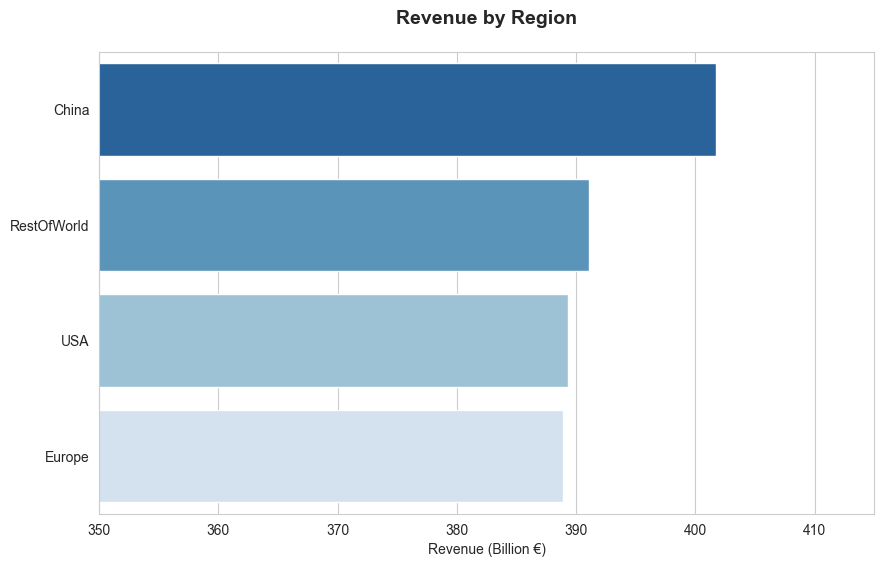

In [123]:
## Revenue by Region (Clustered Bar Chart) | Ingresos por Región (Gráfico de Barras Agrupadas)

region_revenue = df.groupby('region')['revenue_eur'].sum().reset_index()
region_revenue['revenue_billions'] = region_revenue['revenue_eur'] / 1e9
region_revenue = region_revenue.sort_values(by='revenue_billions', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

chart = sns.barplot(
    data=region_revenue,
    x='revenue_billions', 
    y='region', 
    palette="Blues_r",
    hue='region',
    legend=False
)

plt.title('Revenue by Region', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Revenue (Billion €)')
plt.ylabel('')
plt.xlim(350, 415)
plt.show()

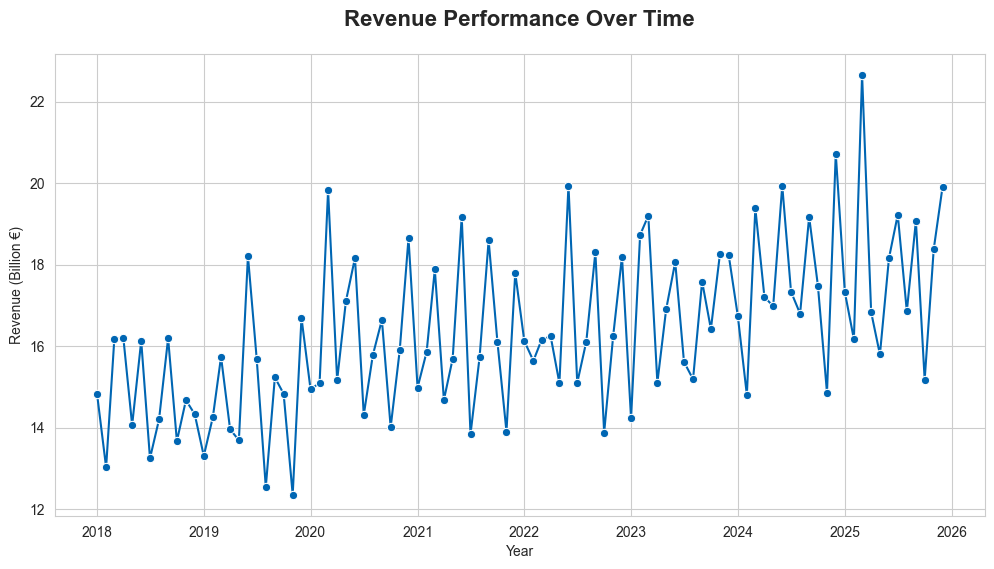

In [124]:
## Revenue Performance Over Time (Line Chart) | Rendimiento de Ingresos en el Tiempo (Gráfico de Lineas)

df['Date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

monthly_data = df.groupby('Date')['revenue_eur'].sum().reset_index()
monthly_data['revenue_billions'] = monthly_data['revenue_eur'] / 1e9

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plot = sns.lineplot(
    data=monthly_data, 
    x='Date', 
    y='revenue_billions', 
    marker='o', 
    color='#0066B3'
)

plt.title('Revenue Performance Over Time', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Revenue (Billion €)')
plt.xlabel('Year')
plt.show()

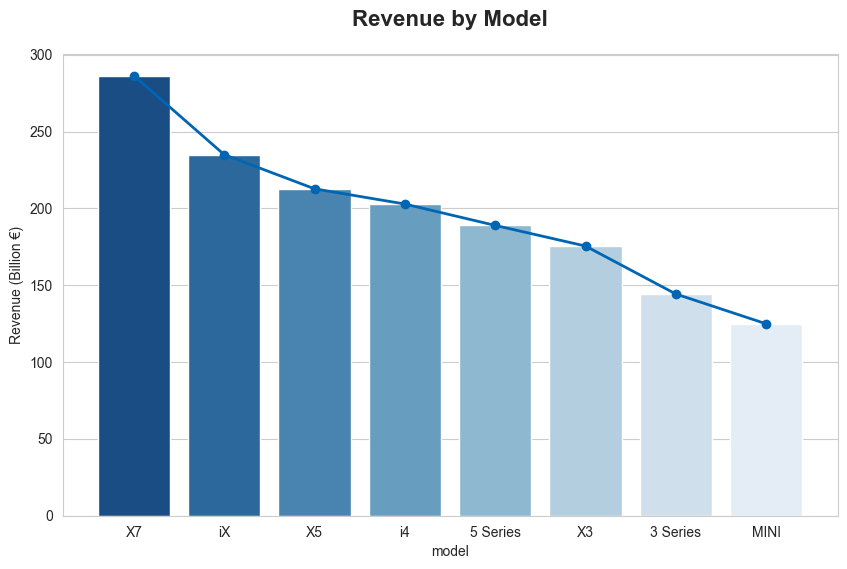

In [125]:
## Revenue by Model (Line and Clustered Column Chart) | Ingresos por Modelo (Gráfico de Líneas y Columnas Agrupadas)

model_revenue = df.groupby('model')['revenue_eur'].sum().reset_index()
model_revenue['revenue_billions'] = model_revenue['revenue_eur'] / 1e9
model_revenue = model_revenue.sort_values(by='revenue_billions', ascending=False)
 
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

chart = sns.barplot(
    data=model_revenue, 
    x='model', 
    y='revenue_billions', 
    palette="Blues_r",
    hue='model',
    legend=False
)

plt.plot(
    model_revenue['model'], 
    model_revenue['revenue_billions'], 
    marker='o', 
    color='#0066B3', 
    linewidth=2
)

plt.title('Revenue by Model', fontsize=16, fontweight='bold', pad=20)
# plt.xlabel('Model Name')
plt.ylabel('Revenue (Billion €)')
plt.show()